# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


### Observaciones iniciales

- El dataset contiene 15.000 registros y 12 variables.
- No se identifican valores nulos en ninguna columna.
- Existen variables numéricas, binarias y categóricas, lo que permitirá aplicar diferentes tipos de análisis de correlación.
- La variable objetivo del análisis será `ingreso_anual`, ya que representa el valor económico generado por cada cliente.
- Las variables `miembro_premium` y `abandono` están codificadas como binarias (0/1).
- Las variables `tipo_dispositivo` y `region` son categóricas.

In [3]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


### 2.1.1. Exploración inicial de los datos

El conjunto de datos contiene 15.000 registros y 12 columnas, sin valores nulos.

#### Variables numéricas

Se identifican las siguientes columnas numéricas:

- edad
- nivel_ingreso
- visitas_mes
- compras_mes
- gasto_publicidad_dirigida
- satisfaccion
- ingreso_anual

La mayoría de estas variables presentan tipos de datos adecuados para el análisis correlacional y no requieren transformación adicional.

#### Variables binarias

Las siguientes columnas representan variables binarias:

- miembro_premium
- abandono

Ambas están codificadas como 0 y 1, por lo que pueden utilizarse directamente en análisis de correlación punto-biserial.

#### Variables categóricas

Se identifican las siguientes columnas categóricas:

- id_cliente
- tipo_dispositivo
- region

Estas variables están correctamente definidas como tipo objeto. La variable id_cliente corresponde a un identificador único y no será utilizada en los análisis de correlación, ya que no aporta información analítica sobre el comportamiento de los clientes.

In [4]:
# Corregir el tipo de dato
df = df.copy()

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


### Diagnóstico inicial de variables numéricas

- **edad** — Los clientes tienen entre 18 y 75 años, con una edad promedio de 38 años. La distribución parece razonablemente equilibrada y representa una población adulta diversa.

- **nivel_ingreso** — El ingreso estimado de los clientes presenta una amplia variabilidad, con valores entre 8.000 y 74.791. Esto sugiere la presencia de diferentes segmentos socioeconómicos dentro de la base de clientes.

- **visitas_mes** — Los usuarios realizan en promedio 10 visitas al mes. La mitad de los clientes registra entre 8 y 12 visitas mensuales, lo que indica un comportamiento relativamente estable de uso de la plataforma.

- **compras_mes** — El promedio es de aproximadamente 1,2 compras por mes. Se observa que al menos el 25% de los usuarios no realiza compras durante el período analizado, mientras que algunos clientes alcanzan hasta 8 compras mensuales.

- **gasto_publicidad_dirigida** — El gasto publicitario asignado muestra una dispersión considerable, con valores entre 0 y 75,5. Esto indica distintos niveles de inversión de marketing según el perfil de cada cliente.

- **satisfaccion** — La satisfacción promedio es de 3,6 sobre 5, con una mediana similar. En general, los clientes presentan una percepción favorable del servicio.

- **ingreso_anual** — Esta es la variable objetivo del análisis. Será necesario examinar su distribución y sus correlaciones con las demás variables para identificar los factores más asociados al valor económico generado por los clientes.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna tenga únicamente dos valores posibles
print("miembro_premium:", df["miembro_premium"].unique())
print("abandono:", df["abandono"].unique())

miembro_premium: [0 1]
abandono: [0 1]


### Diagnóstico inicial de variables binarias

- **miembro_premium** — La variable presenta únicamente los valores 0 y 1, representando correctamente la condición de suscripción premium de los clientes. La codificación es adecuada para aplicar análisis punto-biserial.

- **abandono** — La variable presenta únicamente los valores 0 y 1, indicando si un cliente abandonó o no la plataforma. La estructura es consistente y permite analizar su relación con variables numéricas de negocio.

En ambos casos no se identifican valores atípicos ni categorías adicionales que requieran limpieza o transformación.

#### Explorar variables categóricas

In [8]:
# Verificar el número de valores únicos por variable categórica
print("id_cliente:", df["id_cliente"].nunique())
print("tipo_dispositivo:", df["tipo_dispositivo"].nunique())
print("region:", df["region"].nunique())

id_cliente: 15000
tipo_dispositivo: 3
region: 4


In [9]:
# Explorar variables categóricas y cómo se distribuyen
print("Tipo de dispositivo")
print(df["tipo_dispositivo"].value_counts())

print("\nRegión")
print(df["region"].value_counts())

Tipo de dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Región
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


### Diagnóstico inicial de variables categóricas

- **tipo_dispositivo** — Se identifican tres categorías: móvil, escritorio y tablet. El dispositivo móvil concentra la mayor parte de los usuarios (9.818 registros), seguido por escritorio (3.720) y tablet (1.462). Esto indica una clara predominancia del uso móvil en la plataforma.

- **region** — Se identifican cuatro regiones: norte, sur, este y oeste. La distribución es relativamente equilibrada, aunque la región norte presenta la mayor cantidad de clientes (4.395), mientras que la región este registra la menor participación (3.069).

- **id_cliente** — Contiene 15.000 valores únicos, por lo que funciona como identificador de los registros. Esta variable no aporta valor analítico para el estudio de correlaciones y será excluida de los análisis posteriores.

Las variables categóricas presentan categorías válidas y no se observan inconsistencias ni necesidad de transformaciones adicionales.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

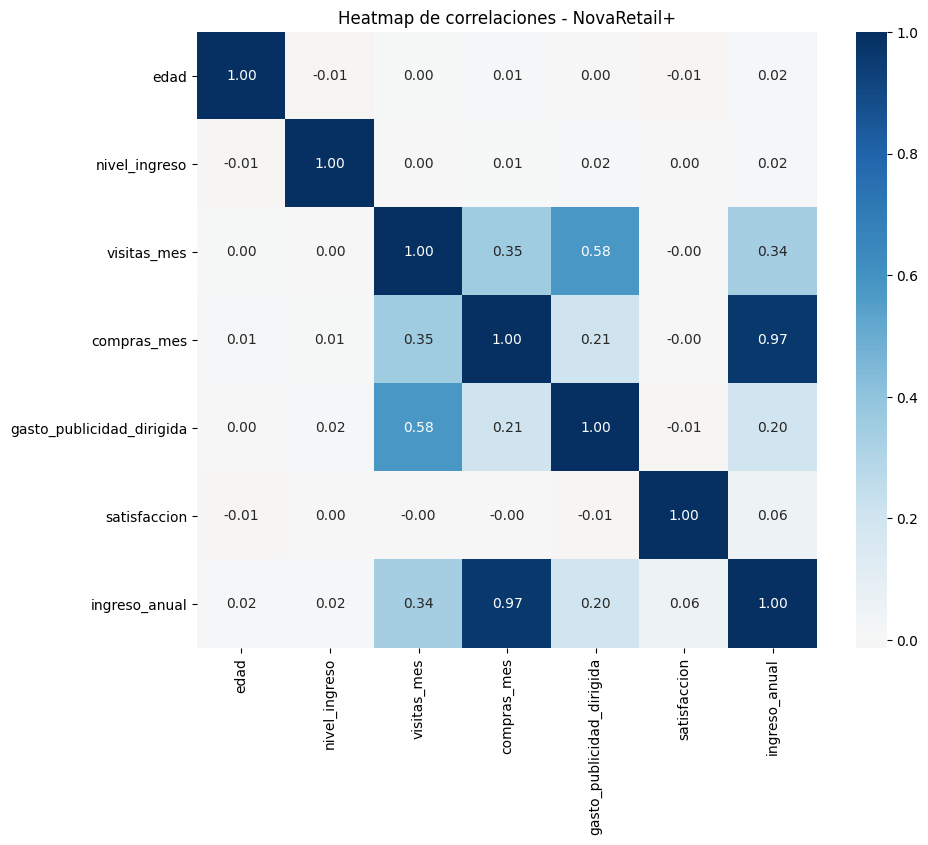

In [10]:
# Visualizar la matriz de correlación para identificar relaciones
# Seleccionar variables numéricas
numeric_cols = [
    'edad',
    'nivel_ingreso',
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'satisfaccion',
    'ingreso_anual'
]

# Matriz de correlación
corr_matrix = df[numeric_cols].corr(method='pearson')

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu',
    center=0,
    fmt='.2f'
)

plt.title('Heatmap de correlaciones - NovaRetail+')
plt.show()

### Observaciones generales (Heatmap)

- La mayoría de las variables demográficas, como edad y nivel_ingreso, presentan correlaciones muy bajas con el resto de variables analizadas.
- Se observa una correlación positiva moderada entre visitas_mes y gasto_publicidad_dirigida (0.58), lo que sugiere una asociación entre la inversión publicitaria y la frecuencia de visitas.
- Existe una correlación positiva moderada entre visitas_mes y compras_mes (0.35), indicando que los usuarios más activos tienden a realizar más compras.
- La variable satisfaccion presenta correlaciones muy bajas con las demás variables, por lo que no parece estar fuertemente asociada con los comportamientos analizados.
- No se identifican problemas evidentes de colinealidad entre las variables explicativas, con excepción de la fuerte relación observada entre compras_mes e ingreso_anual.

### Observaciones respecto a ingreso_anual

- La variable ingreso_anual presenta una correlación muy fuerte con compras_mes (0.97), siendo la relación más relevante identificada en el análisis.
- Se observa una correlación positiva moderada entre ingreso_anual y visitas_mes (0.34), lo que sugiere que una mayor actividad en la plataforma está asociada con mayores ingresos generados.
- La correlación entre ingreso_anual y gasto_publicidad_dirigida es positiva pero débil (0.20).
- Las variables edad (0.02), nivel_ingreso (0.02) y satisfaccion (0.06) muestran una asociación prácticamente nula con ingreso_anual.
- De manera preliminar, las compras realizadas por el cliente parecen ser el principal driver asociado al valor económico generado para la empresa.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

No se considera necesario generar un scatterplot general, ya que el heatmap permitió identificar claramente las relaciones más relevantes entre las variables numéricas. Para un análisis más preciso resulta más útil visualizar únicamente los pares de variables que presentan correlaciones moderadas o fuertes.

### Scatterplot para pares clave

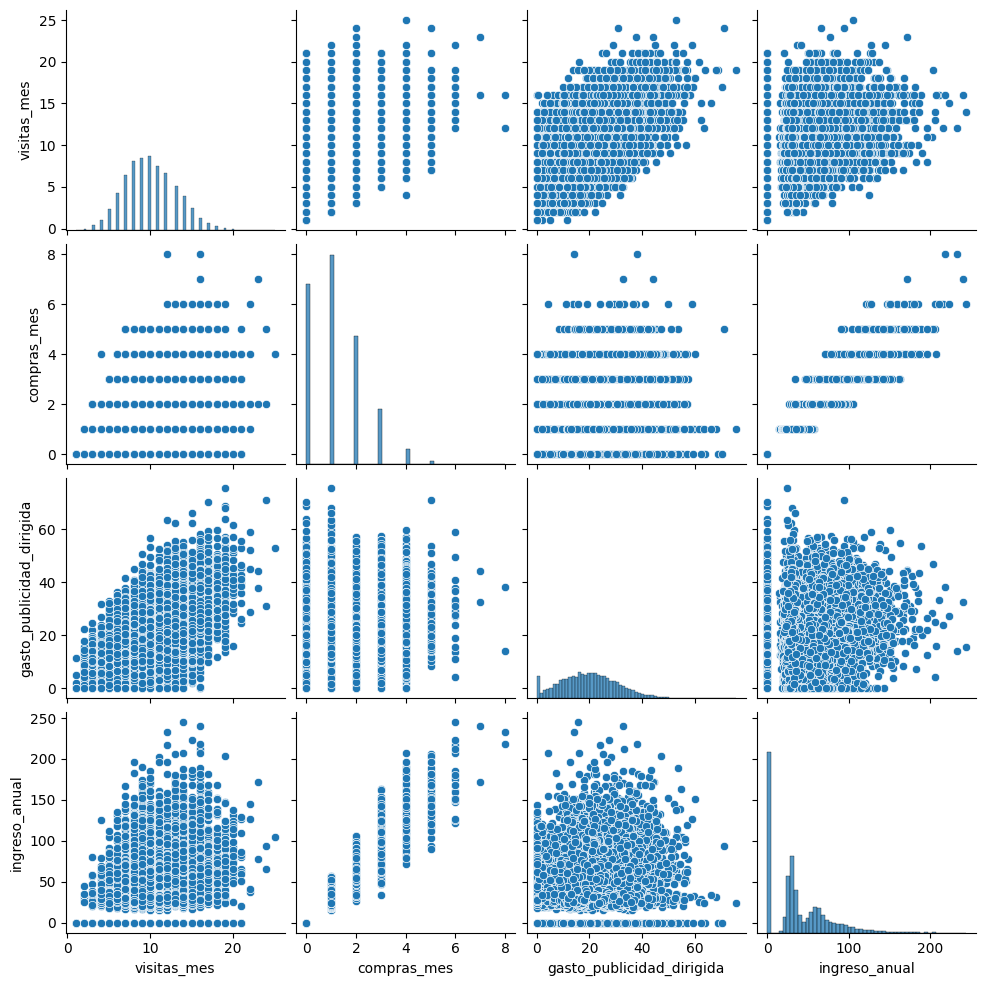

In [12]:
# Visualizar pares de variables con relaciones moderadas o fuertes

cols = [
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'ingreso_anual'
]

sns.pairplot(df[cols])
plt.show()

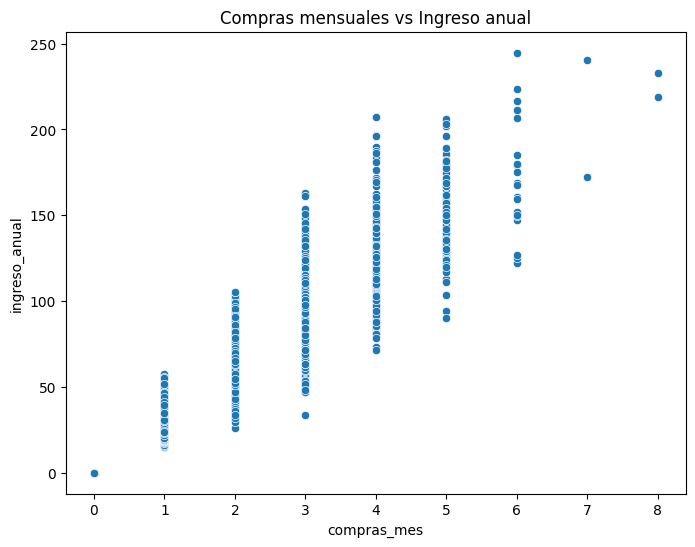

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual'
)

plt.title('Compras mensuales vs Ingreso anual')
plt.show()

### Observaciones iniciales (Scatterplot)

#### compras_mes vs ingreso_anual

- Dirección: positiva.
- Dispersión: baja.
- Se observa una relación muy fuerte entre ambas variables.
- No se identifican outliers extremos.
- La alta asociación observada es consistente con la correlación de Pearson (0.97), por lo que existe evidencia de una posible colinealidad.

#### visitas_mes vs gasto_publicidad_dirigida

- Dirección: positiva.
- Dispersión: media.
- Los clientes con mayor gasto publicitario tienden a registrar más visitas.
- No se observan patrones atípicos relevantes.

#### visitas_mes vs ingreso_anual

- Dirección: positiva.
- Dispersión: media-alta.
- Existe una asociación positiva, aunque más débil que la observada entre compras e ingreso.
- Esto sugiere que las visitas pueden contribuir al ingreso generado, pero no son el único factor relevante.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [14]:
# Calcular correlación entre variables relevantes
pearson_1 = df["compras_mes"].corr(
    df["ingreso_anual"],
    method="pearson"
)

spearman_1 = df["compras_mes"].corr(
    df["ingreso_anual"],
    method="spearman"
)

print("Pearson compras_mes vs ingreso_anual:", pearson_1)
print("Spearman compras_mes vs ingreso_anual:", spearman_1)

Pearson compras_mes vs ingreso_anual: 0.9671485435708564
Spearman compras_mes vs ingreso_anual: 0.967482492032673


In [15]:
# Calcular correlación entre variables relevantes
pearson_2 = df["visitas_mes"].corr(
    df["ingreso_anual"],
    method="pearson"
)

spearman_2 = df["visitas_mes"].corr(
    df["ingreso_anual"],
    method="spearman"
)

print("Pearson visitas_mes vs ingreso_anual:", pearson_2)
print("Spearman visitas_mes vs ingreso_anual:", spearman_2)

Pearson visitas_mes vs ingreso_anual: 0.3371466432498745
Spearman visitas_mes vs ingreso_anual: 0.32095369737696483


### Observaciones de correlación

#### compras_mes vs ingreso_anual

- Correlación Pearson: 0.967
- Correlación Spearman: 0.967
- La relación es positiva y muy fuerte.
- Los valores de Pearson y Spearman son prácticamente idénticos, lo que indica una asociación lineal y consistente.
- Esta es la relación más importante identificada en el análisis.
- La magnitud de la correlación sugiere una posible colinealidad entre ambas variables, por lo que deben interpretarse con cautela en análisis predictivos.

#### visitas_mes vs ingreso_anual

- Correlación Pearson: 0.337
- Correlación Spearman: 0.321
- La relación es positiva y de intensidad moderada.
- La similitud entre ambos coeficientes indica que la asociación es relativamente estable.
- Aunque las visitas están asociadas con mayores ingresos, su capacidad explicativa es considerablemente menor que la observada para compras_mes.
- No se observa evidencia de colinealidad para esta relación.

### Conclusión preliminar

Los resultados confirman que el principal factor asociado al ingreso anual es el número de compras realizadas por el cliente. Las visitas mensuales también muestran una asociación positiva, aunque de menor magnitud. Estos hallazgos son consistentes con los patrones observados previamente en el heatmap y los scatterplots.

### Punto-biserial

In [16]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# miembro_premium vs ingreso_anual
corr_premium, _ = pointbiserialr(
    df["miembro_premium"],
    df["ingreso_anual"]
)

# abandono vs ingreso_anual
corr_abandono, _ = pointbiserialr(
    df["abandono"],
    df["ingreso_anual"]
)

print("Punto-biserial miembro_premium vs ingreso_anual:", corr_premium)
print("Punto-biserial abandono vs ingreso_anual:", corr_abandono)

Punto-biserial miembro_premium vs ingreso_anual: 0.0930994396198015
Punto-biserial abandono vs ingreso_anual: -0.002823934021617148


### Observaciones Punto-biserial

#### miembro_premium vs ingreso_anual

- Correlación punto-biserial: 0.093
- La relación es positiva, pero muy débil.
- Los clientes premium tienden a generar ligeramente más ingresos que los no premium, aunque la magnitud de la asociación es baja.
- La pertenencia al programa premium no parece ser un factor determinante del ingreso anual generado.

#### abandono vs ingreso_anual

- Correlación punto-biserial: -0.003
- La relación es negativa y prácticamente nula.
- No se observa una asociación relevante entre el abandono de la plataforma y el ingreso anual.
- Esta variable no muestra capacidad explicativa sobre el valor económico generado por los clientes.

### Conclusión preliminar

Las variables binarias analizadas presentan asociaciones muy débiles con ingreso_anual. En comparación con las variables de comportamiento, especialmente compras_mes (r = 0.97) y visitas_mes (r = 0.34), su aporte explicativo es limitado.

### V de Cramér

In [17]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(col1, col2):
    tabla = pd.crosstab(col1, col2)

    chi2, _, _, _ = chi2_contingency(tabla)

    n = tabla.sum().sum()

    return np.sqrt(
        chi2 / (n * (min(tabla.shape) - 1))
    )

In [18]:
# Aplicar V de Cramér en variables relevantes
# tipo_dispositivo vs region
v1 = cramers_v(
    df["tipo_dispositivo"],
    df["region"]
)

# tipo_dispositivo vs miembro_premium
v2 = cramers_v(
    df["tipo_dispositivo"],
    df["miembro_premium"]
)

print("V de Cramér tipo_dispositivo vs region:", v1)
print("V de Cramér tipo_dispositivo vs miembro_premium:", v2)


V de Cramér tipo_dispositivo vs region: 0.012378338407739397
V de Cramér tipo_dispositivo vs miembro_premium: 0.01972543445542166


### Observaciones V de Cramér

#### tipo_dispositivo vs region

- V de Cramér: 0.012
- La asociación entre el tipo de dispositivo utilizado y la región del cliente es prácticamente nula.
- El valor obtenido se encuentra muy cerca de cero, indicando independencia entre ambas variables.
- No existe evidencia de una relación relevante entre la ubicación geográfica y el dispositivo utilizado.

#### tipo_dispositivo vs miembro_premium

- V de Cramér: 0.020
- La asociación entre el tipo de dispositivo y la condición de miembro premium es muy débil.
- El valor obtenido sugiere que la suscripción premium no está relacionada con un tipo específico de dispositivo.
- No se identifican patrones de segmentación relevantes entre estas variables.

### Conclusión preliminar

Las variables categóricas analizadas presentan niveles de asociación prácticamente nulos. Esto sugiere que las diferencias en región o tipo de dispositivo no explican de manera significativa el comportamiento económico de los clientes ni otras características relevantes del análisis.

## Sección 5 - Interpretación de resultados para el negocio

---

### Evidencia visual:
El heatmap y el scatterplot muestran una relación positiva muy marcada entre compras_mes e ingreso_anual.

### Evidencia numérica:
- Correlación Pearson: 0.967
- Correlación Spearman: 0.967

### Interpretación

Los clientes que realizan más compras al mes tienden a generar mayores ingresos anuales para la empresa. La asociación observada es extremadamente fuerte y consistente tanto en relaciones lineales como monotónicas.

### No podemos afirmar

No podemos concluir que aumentar directamente el número de compras cause un incremento proporcional en el ingreso anual. La correlación identifica una asociación, pero no demuestra causalidad.

### Implicación de negocio

Las estrategias de crecimiento deberían enfocarse en aumentar la frecuencia de compra de los clientes existentes mediante programas de fidelización, promociones personalizadas y acciones de retención que incentiven compras recurrentes.

### Evidencia visual:
El heatmap y los scatterplots muestran una relación positiva entre visitas_mes e ingreso_anual, aunque con mayor dispersión que la observada para compras_mes.

### Evidencia numérica:
- Correlación Pearson: 0.337
- Correlación Spearman: 0.321

### Interpretación

Los clientes que visitan con mayor frecuencia la plataforma tienden a generar mayores ingresos. Sin embargo, la relación es moderada, lo que indica que la actividad por sí sola no explica completamente el comportamiento de ingresos.

### No podemos afirmar

No podemos afirmar que incrementar el número de visitas provoque automáticamente un aumento en los ingresos. Es posible que otros factores influyan simultáneamente en ambas variables.

### Implicación de negocio

Incrementar la frecuencia de uso de la plataforma puede contribuir a mejorar los resultados comerciales. Acciones enfocadas en engagement, contenido personalizado y campañas de reactivación podrían favorecer un mayor nivel de interacción de los usuarios.

## Sección 6 - Limitaciones y próximos pasos


### Limitaciones

- La correlación no implica causalidad. Las asociaciones identificadas no permiten afirmar que una variable provoque cambios en otra.
- El análisis se basa en datos observacionales y no en experimentos controlados.
- Solo se evaluaron las variables disponibles en el dataset; podrían existir otros factores relevantes no incluidos en el análisis.
- Algunas relaciones pueden estar influenciadas por variables externas no observadas.
- Los resultados representan el comportamiento de los clientes durante el período analizado y podrían variar en otros contextos o períodos de tiempo.
  
### Próximos pasos

#### 1. Profundizar la segmentación de clientes

- Analizar grupos de clientes según frecuencia de compra.
- Identificar segmentos de alto valor y diseñar estrategias específicas para cada uno.

#### 2. Evaluar relaciones mediante modelos predictivos

- Construir modelos de regresión para estimar el impacto conjunto de múltiples variables sobre el ingreso anual.
- Evaluar la importancia relativa de cada variable en la predicción del ingreso.

#### 3. Diseñar experimentos para validar hipótesis

- Implementar pruebas A/B para determinar si acciones orientadas a incrementar las visitas o las compras generan cambios reales en los ingresos.
- Medir el efecto de campañas de marketing y programas de fidelización sobre el comportamiento de compra.

#### 4. Incorporar nuevas variables al análisis

- Historial de compras.
- Tiempo de permanencia en la plataforma.
- Interacción con campañas promocionales.
- Antigüedad del cliente.

### Conclusión general

El análisis permitió identificar que las variables de comportamiento, especialmente el número de compras mensuales, presentan la asociación más fuerte con el ingreso anual generado por los clientes. Por el contrario, las variables demográficas, categóricas y binarias mostraron asociaciones débiles o inexistentes.

Estos resultados sugieren que las estrategias de crecimiento deberían priorizar acciones orientadas a incrementar la frecuencia de compra y la interacción de los clientes con la plataforma. Sin embargo, debido a la naturaleza correlacional del análisis, se recomienda complementar estos hallazgos con modelos predictivos y experimentos controlados antes de tomar decisiones estratégicas definitivas.